# 7×7 Deterministic GridWorld: Value Iteration and Policy Iteration

This notebook solves a $7\times7$ GridWorld with **Value Iteration** and **Policy Iteration**.

The agent starts at $(0,0)$ and must reach the goal at $(6,6)$ while avoiding obstacles. Because the transition and reward model are known, this is a **planning** problem rather than model-free learning.

## 1. Problem

```text
S . . . . . .
. . . . . X .
. . X . . . .
. . . X . . .
. . . . X . .
. . X . . . .
. . . . . . G
```

The algorithms compute the optimal state-value function $V^*(s)$ and an optimal policy $\pi^*(s)$. After planning, the learned/computed policy is simulated from the start state to verify the route to the goal.

## 2. State, Action, Transition, and Reward

### State

A state is the grid position

$$
s=(row,column)
$$

### Action

$$
\mathcal{A}=\{\text{Up},\text{Down},\text{Left},\text{Right}\}
$$

### Transition

For a general stochastic MDP, transitions are described by

$$
P(s'|s,a)
$$

This GridWorld is deterministic, so the selected action has one next state with probability $1$. If the action would leave the grid or enter an obstacle, the agent remains in the same state.

### Reward

$$
R(s,a,s')=
\begin{cases}
+10, & \text{if } s' \text{ is the goal} \\
-5, & \text{if the agent cannot move} \\
-1, & \text{for a normal movement}
\end{cases}
$$

The discount factor is $\gamma=0.9$.


## 3. Imports

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np

## 4. GridWorld Environment

In [2]:
ACTIONS = ("Up", "Down", "Left", "Right")
ACTION_SYMBOLS = {"Up":"↑", "Down":"↓", "Left":"←", "Right":"→"}

class GridWorld:
    def __init__(self):
        self.size = 7
        self.start = (0,0)
        self.goal = (6,6)
        self.obstacles = {(2,2),(3,3),(4,4),(5,2),(1,5)}
        self.states = [(r,c) for r in range(self.size) for c in range(self.size) if (r,c) not in self.obstacles]
        self.decision_states = [s for s in self.states if s != self.goal]

    def deterministic_step(self, state, action):
        r,c = state
        if action == "Up": candidate = (max(r-1,0), c)
        elif action == "Down": candidate = (min(r+1,self.size-1), c)
        elif action == "Left": candidate = (r, max(c-1,0))
        elif action == "Right": candidate = (r, min(c+1,self.size-1))
        else: raise ValueError("Unknown action")

        next_state = state if candidate in self.obstacles else candidate
        if next_state == self.goal: reward = 10.0
        elif next_state == state: reward = -5.0
        else: reward = -1.0
        return next_state, reward

    def transitions(self, state, action):
        # Stochastic-compatible interface: (probability, next_state, reward)
        ns, r = self.deterministic_step(state, action)
        return [(1.0, ns, r)]

    def render_layout(self):
        rows=[]
        for r in range(self.size):
            items=[]
            for c in range(self.size):
                s=(r,c)
                if s==self.start: items.append('S')
                elif s==self.goal: items.append('G')
                elif s in self.obstacles: items.append('X')
                else: items.append('.')
            rows.append(' '.join(items))
        return '\n'.join(rows)

    def render_values(self, V):
        rows=[]
        for r in range(self.size):
            items=[]
            for c in range(self.size):
                s=(r,c)
                if s in self.obstacles: items.append('   X   ')
                elif s==self.goal: items.append('   G   ')
                else: items.append(f'{V[s]:7.2f}')
            rows.append(' '.join(items))
        return '\n'.join(rows)

    def render_policy(self, policy):
        rows=[]
        for r in range(self.size):
            items=[]
            for c in range(self.size):
                s=(r,c)
                if s==self.goal: items.append('G')
                elif s in self.obstacles: items.append('X')
                elif s==self.start: items.append('S'+ACTION_SYMBOLS[policy[s]])
                else: items.append(ACTION_SYMBOLS[policy[s]])
            rows.append(' '.join(items))
        return '\n'.join(rows)

env = GridWorld()
print(env.render_layout())
print('\nValid states:', len(env.states))
print('Decision states:', len(env.decision_states))

S . . . . . .
. . . . . X .
. . X . . . .
. . . X . . .
. . . . X . .
. . X . . . .
. . . . . . G

Valid states: 44
Decision states: 43


## 5. Expected Action Value

For a stochastic MDP,

$$
Q(s,a)=\sum_{s'}P(s'|s,a)\left[R(s,a,s')+\gamma V(s')\right]
$$

The code is written in this general stochastic form. In this deterministic GridWorld, `transitions()` returns only one outcome with probability $1$, so the equation reduces to

$$
Q(s,a)=R(s,a,s')+\gamma V(s')
$$


In [3]:
def expected_action_value(env, V, state, action, gamma=0.9):
    total = 0.0
    for probability, next_state, reward in env.transitions(state, action):
        next_value = 0.0 if next_state == env.goal else V[next_state]
        total += probability * (reward + gamma * next_value)
    return total

# Part I — Value Iteration

## 6. How Value Iteration Works

Value Iteration begins with initial state values, evaluates every available action in each state, and stores the largest expected action value. These Bellman optimality sweeps continue until the values change by less than a small tolerance. After convergence, the action that gives the largest value in each state is selected as the greedy policy.

For a stochastic MDP,

$$
V_{k+1}(s)=\max_a\sum_{s'}P(s'|s,a)\left[R(s,a,s')+\gamma V_k(s')\right].
$$

For this deterministic problem, the probability-weighted sum has one term.

## 7. Value Iteration Algorithm — Stochastic Form

```text
Initialize V(s)=0 for all states

Repeat:
    Δ = 0

    For each nonterminal state s:
        For each action a:
            Q(s,a) = Σ_s' P(s'|s,a)[R(s,a,s') + γV(s')]

        V_new(s) = max_a Q(s,a)
        Δ = max(Δ, |V_new(s)-V(s)|)

    V = V_new

Until Δ < θ

Extract policy:
    π*(s) = argmax_a Σ_s' P(s'|s,a)[R(s,a,s') + γV*(s')]
```

For the deterministic GridWorld, each $\sum_{s'}$ contains only one next state with probability $1$.

## 8. Step 1 — Initialize $V_0(s)$

In [4]:
gamma = 0.9
theta = 1e-4
V0 = {s:0.0 for s in env.states}
print(env.render_values(V0))

   0.00    0.00    0.00    0.00    0.00    0.00    0.00
   0.00    0.00    0.00    0.00    0.00    X       0.00
   0.00    0.00    X       0.00    0.00    0.00    0.00
   0.00    0.00    0.00    X       0.00    0.00    0.00
   0.00    0.00    0.00    0.00    X       0.00    0.00
   0.00    0.00    X       0.00    0.00    0.00    0.00
   0.00    0.00    0.00    0.00    0.00    0.00    G   


## 9. Step 2 — Calculate $Q(s,a)$ for Every Action

In [5]:
demo_state = (5,6)
q0 = {}
print('Demonstration state:', demo_state, '\n')
for action in ACTIONS:
    q = expected_action_value(env, V0, demo_state, action, gamma)
    q0[action] = q
    for p, ns, r in env.transitions(demo_state, action):
        nv = 0.0 if ns == env.goal else V0[ns]
        print(f'{action:>5}: P={p}, next={ns}, reward={r}, V(next)={nv}, Q={q:.4f}')

Demonstration state: (5, 6) 

   Up: P=1.0, next=(4, 6), reward=-1.0, V(next)=0.0, Q=-1.0000
 Down: P=1.0, next=(6, 6), reward=10.0, V(next)=0.0, Q=10.0000
 Left: P=1.0, next=(5, 5), reward=-1.0, V(next)=0.0, Q=-1.0000
Right: P=1.0, next=(5, 6), reward=-5.0, V(next)=0.0, Q=-5.0000


The calculation above follows the stochastic equation. Because the model is deterministic, each action has one listed outcome. For example, moving `Down` from $(5,6)$ enters the goal:

$$
Q((5,6),\text{Down})=1\,[10+0.9(0)]=10.
$$

## 10. Step 3 — Take the Maximum

In [6]:
best_action = max(q0, key=q0.get)
best_value = q0[best_action]
print('Action values:', q0)
print('Best action:', best_action)
print('V_1(5,6) =', best_value)

Action values: {'Up': -1.0, 'Down': 10.0, 'Left': -1.0, 'Right': -5.0}
Best action: Down
V_1(5,6) = 10.0


Value Iteration stores the best **number**:

$$
V_{k+1}(s)=\max_a Q_k(s,a).
$$

The final policy later stores the corresponding **action** using $\arg\max$.

## 11. Step 4 — Perform One Full Bellman Sweep

In [7]:
def value_iteration_sweep(env, V, gamma=0.9):
    new_V = V.copy()
    delta = 0.0
    for state in env.decision_states:
        q_values = [expected_action_value(env,V,state,a,gamma) for a in ACTIONS]
        new_V[state] = max(q_values)
        delta = max(delta, abs(new_V[state]-V[state]))
    return new_V, delta

V1, delta1 = value_iteration_sweep(env, V0, gamma)
print(env.render_values(V1))
print('\nΔ after first sweep =', delta1)

  -1.00   -1.00   -1.00   -1.00   -1.00   -1.00   -1.00
  -1.00   -1.00   -1.00   -1.00   -1.00    X      -1.00
  -1.00   -1.00    X      -1.00   -1.00   -1.00   -1.00
  -1.00   -1.00   -1.00    X      -1.00   -1.00   -1.00
  -1.00   -1.00   -1.00   -1.00    X      -1.00   -1.00
  -1.00   -1.00    X      -1.00   -1.00   -1.00   10.00
  -1.00   -1.00   -1.00   -1.00   -1.00   10.00    G   

Δ after first sweep = 10.0


## 12. Step 5 — Repeat Sweeps Until Convergence

In [23]:
def run_value_iteration(env, gamma=0.9, theta=1e-4):
    V = {s:0.0 for s in env.states}
    history = [V.copy()]
    deltas = []
    sweep_count = 0
    while True:
        sweep_count += 1
        V, delta = value_iteration_sweep(env, V, gamma)
        history.append(V.copy())
        deltas.append(delta)
        print(f'\n--- Sweep {sweep_count} ---')
        print(env.render_values(V))
        if delta < theta:
            break
    return V, history, deltas

vi_values, vi_history, vi_deltas = run_value_iteration(env, gamma, theta)
print('Sweeps:', len(vi_deltas))
print('Final Δ:', vi_deltas[-1])
print('\nFinal values:')
print(env.render_values(vi_values))


--- Sweep 1 ---
  -1.00   -1.00   -1.00   -1.00   -1.00   -1.00   -1.00
  -1.00   -1.00   -1.00   -1.00   -1.00    X      -1.00
  -1.00   -1.00    X      -1.00   -1.00   -1.00   -1.00
  -1.00   -1.00   -1.00    X      -1.00   -1.00   -1.00
  -1.00   -1.00   -1.00   -1.00    X      -1.00   -1.00
  -1.00   -1.00    X      -1.00   -1.00   -1.00   10.00
  -1.00   -1.00   -1.00   -1.00   -1.00   10.00    G   

--- Sweep 2 ---
  -1.90   -1.90   -1.90   -1.90   -1.90   -1.90   -1.90
  -1.90   -1.90   -1.90   -1.90   -1.90    X      -1.90
  -1.90   -1.90    X      -1.90   -1.90   -1.90   -1.90
  -1.90   -1.90   -1.90    X      -1.90   -1.90   -1.90
  -1.90   -1.90   -1.90   -1.90    X      -1.90    8.00
  -1.90   -1.90    X      -1.90   -1.90    8.00   10.00
  -1.90   -1.90   -1.90   -1.90    8.00   10.00    G   

--- Sweep 3 ---
  -2.71   -2.71   -2.71   -2.71   -2.71   -2.71   -2.71
  -2.71   -2.71   -2.71   -2.71   -2.71    X      -2.71
  -2.71   -2.71    X      -2.71   -2.71   -2.71   -2.

## 13. Value Propagation Across Sweeps

In [9]:
tracked = [(5,6),(4,6),(3,6),(0,0)]
print(f"{'Sweep':>5}", *[f'{str(s):>12}' for s in tracked])
for k in range(min(15,len(vi_history))):
    print(f'{k:>5}', *[f'{vi_history[k][s]:>12.4f}' for s in tracked])

Sweep       (5, 6)       (4, 6)       (3, 6)       (0, 0)
    0       0.0000       0.0000       0.0000       0.0000
    1      10.0000      -1.0000      -1.0000      -1.0000
    2      10.0000       8.0000      -1.9000      -1.9000
    3      10.0000       8.0000       6.2000      -2.7100
    4      10.0000       8.0000       6.2000      -3.4390
    5      10.0000       8.0000       6.2000      -4.0951
    6      10.0000       8.0000       6.2000      -4.6856
    7      10.0000       8.0000       6.2000      -5.2170
    8      10.0000       8.0000       6.2000      -5.6953
    9      10.0000       8.0000       6.2000      -6.1258
   10      10.0000       8.0000       6.2000      -6.5132
   11      10.0000       8.0000       6.2000      -6.8619
   12      10.0000       8.0000       6.2000      -3.7238
   13      10.0000       8.0000       6.2000      -3.7238


## 14. Value Iteration Convergence Graph

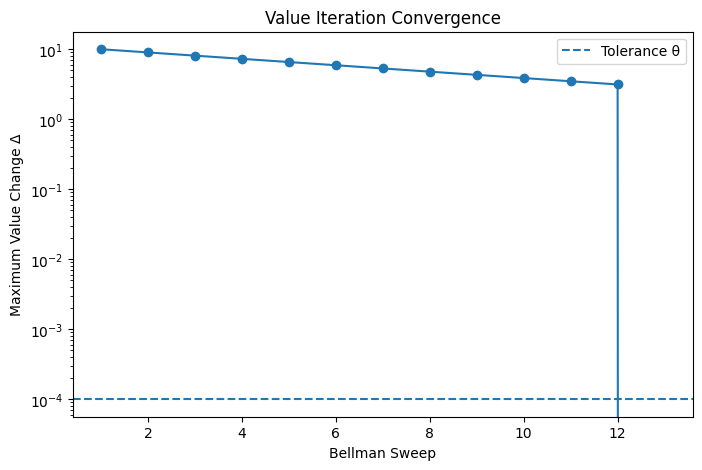

In [24]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(vi_deltas)+1), vi_deltas, marker='o')
plt.axhline(theta, linestyle='--', label='Tolerance θ')
plt.yscale('log')
plt.xlabel('Bellman Sweep')
plt.ylabel('Maximum Value Change Δ')
plt.title('Value Iteration Convergence')
plt.legend()
plt.show()

## 15. Step 6 — Extract the Greedy Policy

In [25]:
def extract_policy(env, V, gamma=0.9):
    policy={}; q_tables={}
    for state in env.decision_states:
        q_values={a:expected_action_value(env,V,state,a,gamma) for a in ACTIONS}
        q_tables[state]=q_values
        policy[state]=max(ACTIONS,key=lambda a:q_values[a])
    return policy, q_tables

vi_policy, vi_q_tables = extract_policy(env, vi_values, gamma)
print(env.render_policy(vi_policy))

state=(0,0)
print('\nFinal action values at', state)
for a,v in vi_q_tables[state].items(): print(f'{a:>5}: {v:.4f}')
print('Selected action:', vi_policy[state])

S↓ ↓ ↓ ↓ ↓ → ↓
↓ ↓ → ↓ ↓ X ↓
↓ ↓ X → ↓ ↓ ↓
↓ ↓ ↓ X → ↓ ↓
↓ ↓ → ↓ X ↓ ↓
↓ ↓ X ↓ ↓ ↓ ↓
→ → → → → → G

Final action values at (0, 0)
   Up: -8.3514
 Down: -3.7238
 Left: -8.3514
Right: -3.7238
Selected action: Down


The policy uses

$$
\pi^*(s)=\arg\max_a\sum_{s'}P(s'|s,a)[R(s,a,s')+\gamma V^*(s')].
$$

Again, the deterministic example has one next-state term for each action.

## 16. Value Iteration Simulation

In [26]:
def render_agent(env, state):
    rows=[]
    for r in range(env.size):
        items=[]
        for c in range(env.size):
            cell=(r,c)
            if cell==state: items.append('A')
            elif cell==env.goal: items.append('G')
            elif cell in env.obstacles: items.append('X')
            else: items.append('-')
        rows.append(' '.join(items))
    print('\n'.join(rows)); print()

def simulate_policy(env, policy, pause=0.0, max_steps=50):
    state=env.start; trajectory=[state]; total_reward=0.0
    print('Initial state:'); render_agent(env,state)
    for step in range(1,max_steps+1):
        if state==env.goal: break
        action=policy[state]
        next_state,reward=env.deterministic_step(state,action)
        trajectory.append(next_state); total_reward += reward
        print(f'Step {step}: {state} --{action}--> {next_state} | reward={reward}')
        state=next_state; render_agent(env,state)
        if pause>0: time.sleep(pause)
        if state==env.goal: break
    return {'trajectory':trajectory,'steps':len(trajectory)-1,'reward':total_reward,'goal_reached':state==env.goal}

vi_sim = simulate_policy(env, vi_policy, pause=0.0)
print('Goal reached:', vi_sim['goal_reached'])
print('Steps:', vi_sim['steps'])
print('Total reward:', vi_sim['reward'])

Initial state:
A - - - - - -
- - - - - X -
- - X - - - -
- - - X - - -
- - - - X - -
- - X - - - -
- - - - - - G

Step 1: (0, 0) --Down--> (1, 0) | reward=-1.0
- - - - - - -
A - - - - X -
- - X - - - -
- - - X - - -
- - - - X - -
- - X - - - -
- - - - - - G

Step 2: (1, 0) --Down--> (2, 0) | reward=-1.0
- - - - - - -
- - - - - X -
A - X - - - -
- - - X - - -
- - - - X - -
- - X - - - -
- - - - - - G

Step 3: (2, 0) --Down--> (3, 0) | reward=-1.0
- - - - - - -
- - - - - X -
- - X - - - -
A - - X - - -
- - - - X - -
- - X - - - -
- - - - - - G

Step 4: (3, 0) --Down--> (4, 0) | reward=-1.0
- - - - - - -
- - - - - X -
- - X - - - -
- - - X - - -
A - - - X - -
- - X - - - -
- - - - - - G

Step 5: (4, 0) --Down--> (5, 0) | reward=-1.0
- - - - - - -
- - - - - X -
- - X - - - -
- - - X - - -
- - - - X - -
A - X - - - -
- - - - - - G

Step 6: (5, 0) --Down--> (6, 0) | reward=-1.0
- - - - - - -
- - - - - X -
- - X - - - -
- - - X - - -
- - - - X - -
- - X - - - -
A - - - - - G

Step 7: (6, 0) -

# Part II — Policy Iteration

## 17. How Policy Iteration Works

Policy Iteration starts with an initial policy. It first evaluates that fixed policy until $V^\pi$ converges. Then it improves the policy by comparing every action and selecting the greedy action. Evaluation and improvement alternate until the policy stops changing.

## 18. Policy Iteration Algorithm — Stochastic Form

```text
Initialize any policy π

Repeat:

    Policy Evaluation:
        Initialize V(s)
        Repeat:
            Δ = 0
            For each nonterminal state s:
                V_new(s) = Σ_s' P(s'|s,π(s))
                           [R(s,π(s),s') + γV(s')]
                Δ = max(Δ, |V_new(s)-V(s)|)
            V = V_new
        Until Δ < θ

    Policy Improvement:
        policy_stable = True

        For each nonterminal state s:
            old_action = π(s)

            For every action a:
                Q^π(s,a) = Σ_s' P(s'|s,a)
                           [R(s,a,s') + γV^π(s')]

            π(s) = argmax_a Q^π(s,a)

            If π(s) != old_action:
                policy_stable = False

Until policy_stable = True
```

In the deterministic GridWorld, every probability-weighted sum again reduces to one next-state term.

## 19. Step 1 — Initialize the Policy

In [13]:
initial_policy = {s:'Up' for s in env.decision_states}
print(env.render_policy(initial_policy))

S↑ ↑ ↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑ X ↑
↑ ↑ X ↑ ↑ ↑ ↑
↑ ↑ ↑ X ↑ ↑ ↑
↑ ↑ ↑ ↑ X ↑ ↑
↑ ↑ X ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑ ↑ G


## 20. Step 2 — Policy Evaluation

For a stochastic MDP with a deterministic policy,

$$
V_{k+1}^{\pi}(s)=\sum_{s'}P(s'|s,\pi(s))\left[R(s,\pi(s),s')+\gamma V_k^{\pi}(s')\right].
$$

There is **no $\max$** during Policy Evaluation because the current policy already specifies the action. For this deterministic environment, the sum contains only one outcome.

In [28]:
def policy_evaluation(env, policy, gamma=0.9, theta=1e-4, print_sweeps=False):
    V={s:0.0 for s in env.states}; history=[V.copy()]; deltas=[]
    sweep_count = 0
    while True:
        sweep_count += 1
        new_V=V.copy(); delta=0.0
        for state in env.decision_states:
            action=policy[state]
            new_V[state]=expected_action_value(env,V,state,action,gamma)
            delta=max(delta,abs(new_V[state]-V[state]))
        V=new_V; history.append(V.copy()); deltas.append(delta)
        if print_sweeps:
            print(f'\n--- Policy Evaluation Sweep {sweep_count} ---')
            print(env.render_values(V))
        if delta<theta: break
    return V,history,deltas

## 21. Code-Generated Policy Evaluation Example

In [15]:
state=(0,0); action=initial_policy[state]; V=initial_eval_history[0]
print('State:',state,'| Policy action:',action)
for p,ns,r in env.transitions(state,action):
    nv=0.0 if ns==env.goal else V[ns]
    contribution=p*(r+gamma*nv)
    print('P=',p,'next=',ns,'reward=',r,'V(next)=',nv,'contribution=',contribution)
print('V_1^π(0,0) =', expected_action_value(env,V,state,action,gamma))

State: (0, 0) | Policy action: Up
P= 1.0 next= (0, 0) reward= -5.0 V(next)= 0.0 contribution= -5.0
V_1^π(0,0) = -5.0


The current policy says `Up`. At $(0,0)$, that action cannot move outside the grid, so the agent remains in $(0,0)$ and receives $-5$. A stochastic environment would sum over all possible next states; here only one transition occurs.

## 22. Policy Evaluation Convergence Graph

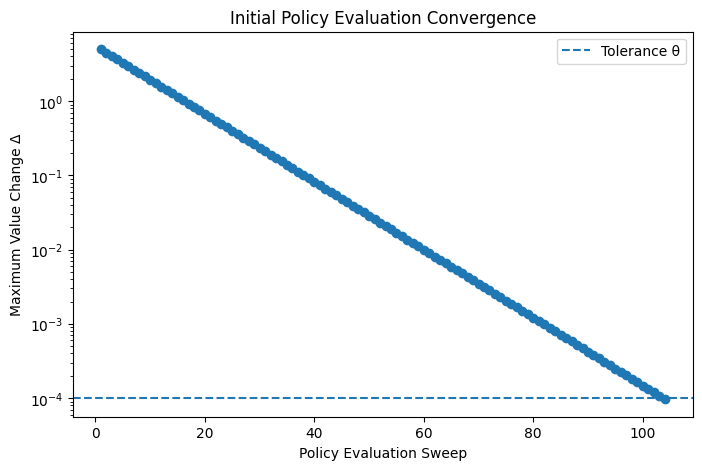

In [16]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(initial_eval_deltas)+1), initial_eval_deltas, marker='o')
plt.axhline(theta, linestyle='--', label='Tolerance θ')
plt.yscale('log')
plt.xlabel('Policy Evaluation Sweep')
plt.ylabel('Maximum Value Change Δ')
plt.title('Initial Policy Evaluation Convergence')
plt.legend(); plt.show()

## 23. Step 3 — Policy Improvement

After $V^\pi$ converges, compare all actions:

$$
Q^\pi(s,a)=\sum_{s'}P(s'|s,a)\left[R(s,a,s')+\gamma V^\pi(s')\right].
$$

Then choose

$$
\pi_{new}(s)=\arg\max_a Q^\pi(s,a).
$$

In [17]:
def policy_improvement(env,V,current_policy,gamma=0.9):
    new_policy=current_policy.copy(); q_tables={}; changes=0
    for state in env.decision_states:
        q_values={a:expected_action_value(env,V,state,a,gamma) for a in ACTIONS}
        q_tables[state]=q_values
        best=max(ACTIONS,key=lambda a:q_values[a])
        if best!=current_policy[state]: changes += 1
        new_policy[state]=best
    return new_policy,q_tables,changes

improved_policy, first_pi_q, first_changes = policy_improvement(env, initial_values, initial_policy, gamma)
print('Policy changes after first improvement:', first_changes)

state=(5,6)
print('\nState:',state,'| Old action:',initial_policy[state])
for a,v in first_pi_q[state].items():
    p,ns,r=env.transitions(state,a)[0]
    print(f'{a:>5}: P={p}, next={ns}, reward={r}, Q={v:.4f}')
print('Improved action:', improved_policy[state])

Policy changes after first improvement: 41

State: (5, 6) | Old action: Up
   Up: P=1.0, next=(4, 6), reward=-1.0, Q=-33.6188
 Down: P=1.0, next=(6, 6), reward=10.0, Q=10.0000
 Left: P=1.0, next=(5, 5), reward=-1.0, Q=-36.2432
Right: P=1.0, next=(5, 6), reward=-5.0, Q=-35.2569
Improved action: Down


## 24. Step 4 — Repeat Evaluation and Improvement Until Stable

In [30]:
def run_policy_iteration(env,gamma=0.9,theta=1e-4):
    policy={s:'Up' for s in env.decision_states}; history=[]
    cycle_count = 0
    while True:
        cycle_count += 1
        print(f'\n==== Policy Iteration Cycle {cycle_count} ====\n')
        V,_,eval_deltas=policy_evaluation(env,policy,gamma,theta, print_sweeps=True)
        new_policy,q_tables,changes=policy_improvement(env,V,policy,gamma)
        history.append({'values':V.copy(),'policy_changes':changes,'evaluation_sweeps':len(eval_deltas),'q_tables':q_tables})
        policy=new_policy
        if changes==0: break
    return V,policy,history

pi_values, pi_policy, pi_history = run_policy_iteration(env,gamma,theta)
for i,rec in enumerate(pi_history,1):
    print(f'Cycle {i}: evaluation sweeps={rec["evaluation_sweeps"]}, policy changes={rec["policy_changes"]}')


==== Policy Iteration Cycle 1 ====


--- Policy Evaluation Sweep 1 ---
  -5.00   -5.00   -5.00   -5.00   -5.00   -5.00   -5.00
  -1.00   -1.00   -1.00   -1.00   -1.00    X      -1.00
  -1.00   -1.00    X      -1.00   -1.00   -5.00   -1.00
  -1.00   -1.00   -5.00    X      -1.00   -1.00   -1.00
  -1.00   -1.00   -1.00   -5.00    X      -1.00   -1.00
  -1.00   -1.00    X      -1.00   -5.00   -1.00   -1.00
  -1.00   -1.00   -5.00   -1.00   -1.00   -1.00    G   

--- Policy Evaluation Sweep 2 ---
  -9.50   -9.50   -9.50   -9.50   -9.50   -9.50   -9.50
  -5.50   -5.50   -5.50   -5.50   -5.50    X      -5.50
  -1.90   -1.90    X      -1.90   -1.90   -9.50   -1.90
  -1.90   -1.90   -9.50    X      -1.90   -5.50   -1.90
  -1.90   -1.90   -5.50   -9.50    X      -1.90   -1.90
  -1.90   -1.90    X      -5.50   -9.50   -1.90   -1.90
  -1.90   -1.90   -9.50   -1.90   -5.50   -1.90    G   

--- Policy Evaluation Sweep 3 ---
 -13.55  -13.55  -13.55  -13.55  -13.55  -13.55  -13.55
  -9.55   -9.55   

## 25. Policy Iteration Convergence Graphs

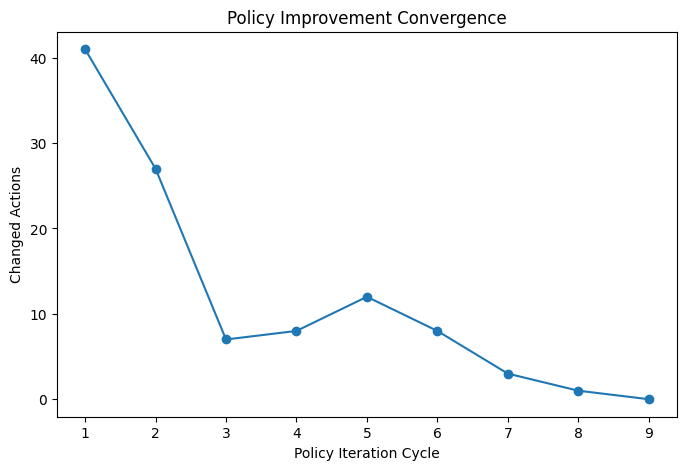

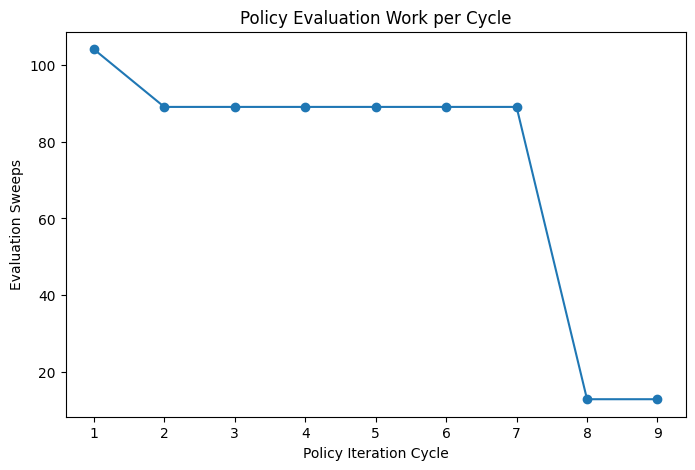

In [19]:
cycles=np.arange(1,len(pi_history)+1)
changes=[r['policy_changes'] for r in pi_history]
sweeps=[r['evaluation_sweeps'] for r in pi_history]

plt.figure(figsize=(8,5))
plt.plot(cycles,changes,marker='o')
plt.xlabel('Policy Iteration Cycle'); plt.ylabel('Changed Actions')
plt.title('Policy Improvement Convergence'); plt.show()

plt.figure(figsize=(8,5))
plt.plot(cycles,sweeps,marker='o')
plt.xlabel('Policy Iteration Cycle'); plt.ylabel('Evaluation Sweeps')
plt.title('Policy Evaluation Work per Cycle'); plt.show()

## 26. Final Policy Iteration Values and Policy

In [20]:
print('Final value function:')
print(env.render_values(pi_values))
print('\nFinal policy:')
print(env.render_policy(pi_policy))

Final value function:
  -3.72   -3.03   -2.25   -1.39   -0.43    0.63    1.81
  -3.03   -2.25   -1.39   -0.43    0.63    X       3.12
  -2.25   -1.39    X       0.63    1.81    3.12    4.58
  -1.39   -0.43    0.63    X       3.12    4.58    6.20
  -0.43    0.63    1.81    3.12    X       6.20    8.00
   0.63    1.81    X       4.58    6.20    8.00   10.00
   1.81    3.12    4.58    6.20    8.00   10.00    G   

Final policy:
S↓ ↓ ↓ ↓ ↓ → ↓
↓ ↓ → ↓ ↓ X ↓
↓ ↓ X → ↓ ↓ ↓
↓ ↓ ↓ X → ↓ ↓
↓ ↓ → ↓ X ↓ ↓
↓ ↓ X ↓ ↓ ↓ ↓
→ → → → → → G


## 27. Policy Iteration Simulation

In [21]:
pi_sim = simulate_policy(env, pi_policy, pause=0.0)
print('Goal reached:', pi_sim['goal_reached'])
print('Steps:', pi_sim['steps'])
print('Total reward:', pi_sim['reward'])

Initial state:
A - - - - - -
- - - - - X -
- - X - - - -
- - - X - - -
- - - - X - -
- - X - - - -
- - - - - - G

Step 1: (0, 0) --Down--> (1, 0) | reward=-1.0
- - - - - - -
A - - - - X -
- - X - - - -
- - - X - - -
- - - - X - -
- - X - - - -
- - - - - - G

Step 2: (1, 0) --Down--> (2, 0) | reward=-1.0
- - - - - - -
- - - - - X -
A - X - - - -
- - - X - - -
- - - - X - -
- - X - - - -
- - - - - - G

Step 3: (2, 0) --Down--> (3, 0) | reward=-1.0
- - - - - - -
- - - - - X -
- - X - - - -
A - - X - - -
- - - - X - -
- - X - - - -
- - - - - - G

Step 4: (3, 0) --Down--> (4, 0) | reward=-1.0
- - - - - - -
- - - - - X -
- - X - - - -
- - - X - - -
A - - - X - -
- - X - - - -
- - - - - - G

Step 5: (4, 0) --Down--> (5, 0) | reward=-1.0
- - - - - - -
- - - - - X -
- - X - - - -
- - - X - - -
- - - - X - -
A - X - - - -
- - - - - - G

Step 6: (5, 0) --Down--> (6, 0) | reward=-1.0
- - - - - - -
- - - - - X -
- - X - - - -
- - - X - - -
- - - - X - -
- - X - - - -
A - - - - - G

Step 7: (6, 0) -

# Part III — Final Comparison

## 28. Value Iteration vs. Policy Iteration

Both methods use the same known stochastic-form model equations. The environment happens to be deterministic, so each probability sum collapses to one next state.

In [22]:
max_diff=max(abs(vi_values[s]-pi_values[s]) for s in env.states)
agreement=sum(vi_policy[s]==pi_policy[s] for s in env.decision_states)
print('Maximum value difference:',max_diff)
print('Matching actions:',agreement,'out of',len(env.decision_states))
print('Policy agreement:',agreement/len(env.decision_states))
print('\nValue Iteration trajectory:',vi_sim['trajectory'])
print('Policy Iteration trajectory:',pi_sim['trajectory'])
print('Same trajectory:',vi_sim['trajectory']==pi_sim['trajectory'])

Maximum value difference: 0.0
Matching actions: 43 out of 43
Policy agreement: 1.0

Value Iteration trajectory: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
Policy Iteration trajectory: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
Same trajectory: True


## 29. Summary

| Feature | Value Iteration | Policy Iteration |
|---|---|---|
| Known model required | Yes | Yes |
| Fixed-policy evaluation | No | Yes |
| $\max_a$ during value updates | Yes | No |
| $\arg\max_a$ | Final policy extraction | Policy Improvement |
| Main loop | Bellman optimality sweeps | Evaluation → Improvement |
| Final output | $V^*$ and $\pi^*$ | $V^*$ and $\pi^*$ |

The algorithms above are written using the **general stochastic Dynamic Programming equations**. The deterministic GridWorld simply makes each expected backup easier to inspect because $P(s'|s,a)=1$ for a single resulting state.